<a href="https://colab.research.google.com/github/m1deey/My_LinearRegression_library-/blob/main/Main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Version two
It can use multiple features

In [19]:
import numpy as np

class LinearRegression:
    def __init__(self, learning_rate=0.01, epochs=1000):
        self.w = None
        self.b = 0
        self.learning_rate = learning_rate
        self.epochs = epochs

    def predict(self, X):
        return np.dot(X, self.w) + self.b

    def fit(self, X_train, y_train):

        n_features = X_train.shape[1]


        self.w = np.zeros(n_features)
        self.losses = []


        for _ in range(self.epochs):



            y_pred = self.predict(X_train)

            loss = np.mean((y_pred - y_train) ** 2)


            dw = (2 / len(X_train)) * np.dot(X_train.T, (y_pred - y_train))
            db = (2 / len(X_train)) * np.sum(y_pred - y_train)


            self.w -= self.learning_rate * dw
            self.b -= self.learning_rate * db
            self.losses.append(loss)
        return self
    def mse(self, y_true, y_pred):
        return np.mean((y_true - y_pred) ** 2)
    def score(self, X, y):

        y_pred = self.predict(X)

        ss_res = np.sum((y - y_pred) ** 2)

        ss_tot = np.sum((y - np.mean(y)) ** 2)

        return 1 - (ss_res / ss_tot)

#Test

In [9]:
X_train = np.array([
    [1, 2],
    [2, 1],
    [3, 4],
    [4, 2],
    [5, 3]
])

y_train = np.array([9, 8, 17, 16, 22])

model = LinearRegression(learning_rate=0.01, epochs=1000)

model.fit(X_train, y_train)

print("Weights:", model.w)
print("Bias:", model.b)

new_data = np.array([[6, 4]])
print("Prediction:", model.predict(new_data))

Weights: [2.77489689 2.09875188]
Bias: 1.0353982095175518
Prediction: [26.07978709]


#comparing with sklearn

In [10]:
from sklearn.linear_model import LinearRegression

sk_model = LinearRegression()
sk_model.fit(X_train, y_train)

print("-- My Model --")
print("Weights:", model.w)
print("Bias:", model.b)
print("Prediction:", model.predict(np.array([[6, 4]])))

print("-- Sklearn --")
print("Weights:", sk_model.coef_)
print("Bias:", sk_model.intercept_)
print("Prediction:", sk_model.predict(np.array([[6, 4]])))

-- My Model --
Weights: [2.77489689 2.09875188]
Bias: 1.0353982095175518
Prediction: [26.07978709]
-- Sklearn --
Weights: [2.77209302 2.09302326]
Bias: 1.0604651162790741
Prediction: [26.06511628]


The results are close

#R2 score and MSE

In [21]:
from sklearn.metrics import r2_score,mean_squared_error
y_pred=model.predict(X_train)
print("--my model--")
print("MSE=",model.mse(y_train,y_pred))
print("R²=",model.score(X_train,y_train))
print("--sklearn--")
print("mse=", mean_squared_error(y_train,y_pred))
print("R²=", r2_score(y_train,y_pred))

--my model--
MSE= 0.5526357158264965
R²= 0.9798602144378099
--sklearn--
mse= 0.5526357158264965
R²= 0.9798602144378099


The same as sklearn

# Vasule of how Data trained

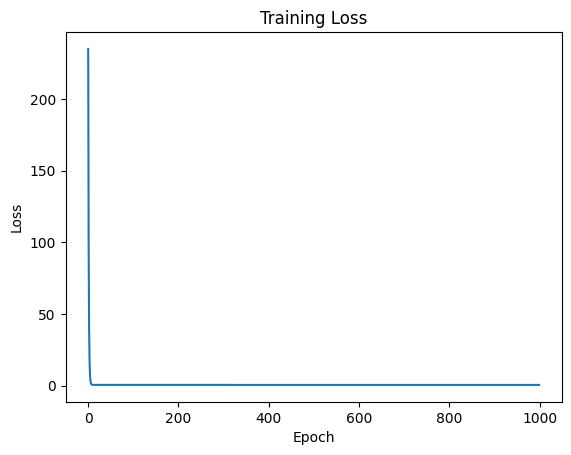

In [20]:
import matplotlib.pyplot as plt

plt.plot(model.losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()